# Árboles de Regresión - Optimización y Comparación

Este notebook entrena múltiples árboles de regresión, evalúa su desempeño usando RMSE y los compara con un modelo de regresión lineal.

In [7]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_parquet("data/listings_clean.parquet")
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city,log_price
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas",4.584967
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas",5.081404
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas",3.663562
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas",4.983607
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas",4.077537


In [9]:
# eliminar solo filas donde falta el precio
df = df.dropna(subset=["price"])

# seleccionar solo variables numéricas
df_numeric = df.select_dtypes(include=[np.number])

# rellenar nulos con la media
df_numeric = df_numeric.fillna(df_numeric.mean())

# variable objetivo
y = df_numeric["price"]

# features
X = df_numeric.drop(columns=["price"])

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
depths = [3, 5, 10]
results = []

for d in depths:
    model = DecisionTreeRegressor(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    results.append((d, rmse))
    print(f"Depth: {d} -> RMSE: {rmse:.2f}")

Depth: 3 -> RMSE: 259.53
Depth: 5 -> RMSE: 77.55
Depth: 10 -> RMSE: 37.43


In [12]:
results_df = pd.DataFrame(results, columns=["depth", "rmse"])
results_df

,depth,rmse
0,3,259.533421
1,5,77.545826
2,10,37.425732


In [13]:
best_depth = results_df.loc[results_df["rmse"].idxmin(), "depth"]
print("Mejor depth:", best_depth)

Mejor depth: 10


In [14]:
best_tree = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
best_tree.fit(X_train, y_train)

preds_tree = best_tree.predict(X_test)
rmse_tree = np.sqrt(mean_squared_error(y_test, preds_tree))

print("RMSE mejor árbol:", rmse_tree)

RMSE mejor árbol: 37.42573191418413


In [15]:
lr = LinearRegression()
lr.fit(X_train, y_train)

preds_lr = lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, preds_lr))

print("RMSE Regresión Lineal:", rmse_lr)

RMSE Regresión Lineal: 4297.591279895825


In [16]:
print("\n--- COMPARACIÓN ---")
print(f"Árbol (depth={best_depth}): {rmse_tree:.2f}")
print(f"Regresión Lineal: {rmse_lr:.2f}")


--- COMPARACIÓN ---
Árbol (depth=10): 37.43
Regresión Lineal: 4297.59


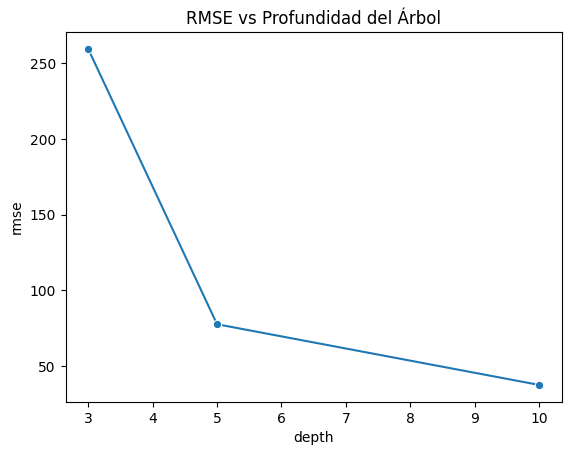

In [17]:
sns.lineplot(data=results_df, x="depth", y="rmse", marker="o")
plt.title("RMSE vs Profundidad del Árbol")
plt.show()